# Movie Rating Prediction

### Importing libraries and dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_excel('IMDB-MOvie-Data.xlsx')

In [5]:
df.head(10)

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0
5,6,The Great Wall,"Action,Adventure,Fantasy",European mercenaries searching for black powde...,Yimou Zhang,"Matt Damon, Tian Jing, Willem Dafoe, Andy Lau",2016,103,6.1,56036,45.13,42.0
6,7,La La Land,"Comedy,Drama,Music",A jazz pianist falls for an aspiring actress i...,Damien Chazelle,"Ryan Gosling, Emma Stone, Rosemarie DeWitt, J....",2016,128,8.3,258682,151.06,93.0
7,8,Mindhorn,Comedy,A has-been actor best known for playing the ti...,Sean Foley,"Essie Davis, Andrea Riseborough, Julian Barrat...",2016,89,6.4,2490,NaN,71.0
8,9,The Lost City of Z,"Action,Adventure,Biography","A true-life drama, centering on British explor...",James Gray,"Charlie Hunnam, Robert Pattinson, Sienna Mille...",2016,141,7.1,7188,8.01,78.0
9,10,Passengers,"Adventure,Drama,Romance",A spacecraft traveling to a distant colony pla...,Morten Tyldum,"Jennifer Lawrence, Chris Pratt, Michael Sheen,...",2016,116,7.0,192177,100.01,41.0


In [6]:
df.shape

(1000, 12)

### Basic statistics

In [7]:
df.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [9]:
df.dtypes

Rank                    int64
Title                  object
Genre                  object
Description            object
Director               object
Actors                 object
Year                    int64
Runtime (Minutes)       int64
Rating                float64
Votes                   int64
Revenue (Millions)    float64
Metascore             float64
dtype: object

### Handling null values

In [10]:
df.isnull().sum()

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64

<Axes: >

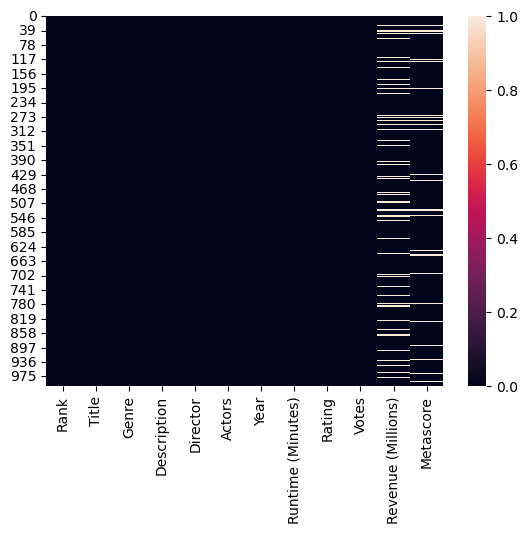

In [11]:
sns.heatmap(df.isnull())

In [35]:
per_missing = df.isnull().sum() * 100 / len(df)
per_missing

Rank                   0.0
Title                  0.0
Genre                  0.0
Description            0.0
Director               0.0
Actors                 0.0
Year                   0.0
Runtime (Minutes)      0.0
Rating                 0.0
Votes                  0.0
Revenue (Millions)    12.8
Metascore              6.4
dtype: float64

In [197]:
# df.columns

In [40]:
# Revenue (median)
df['Revenue (Millions)'].fillna(df['Revenue (Millions)'].median(), inplace=True)

In [41]:
# Metascore (mean)
df['Metascore'].fillna(df['Metascore'].mean(), inplace=True)

In [25]:
df.isnull().sum()

Rank                  0
Title                 0
Genre                 0
Description           0
Director              0
Actors                0
Year                  0
Runtime (Minutes)     0
Rating                0
Votes                 0
Revenue (Millions)    0
Metascore             0
dtype: int64

### Handling duplicated values

In [45]:
df.duplicated().any()

np.False_

There is no duplicate value in this dataset

### Data visualization

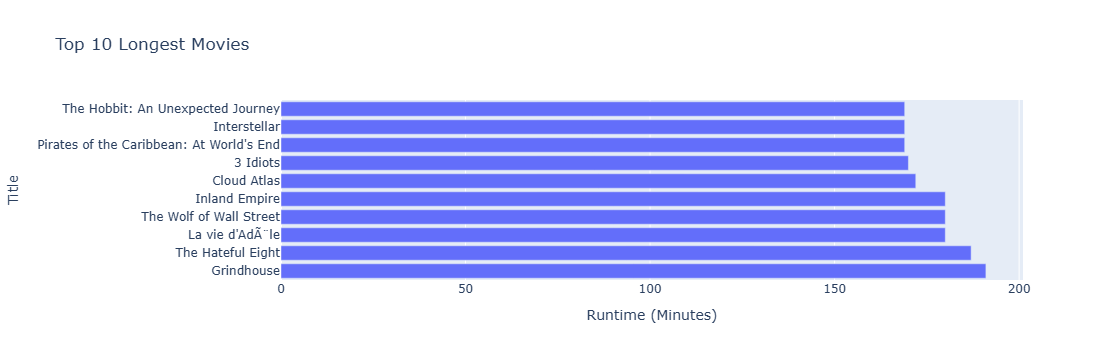

In [68]:
# Top 10 longest movies
top_runtime = df.sort_values(by='Runtime (Minutes)', ascending=False).head(10)

fig = px.bar(
    top_runtime,
    x='Runtime (Minutes)',
    y='Title',
    orientation='h',
    title='Top 10 Longest Movies'
)
fig.show()

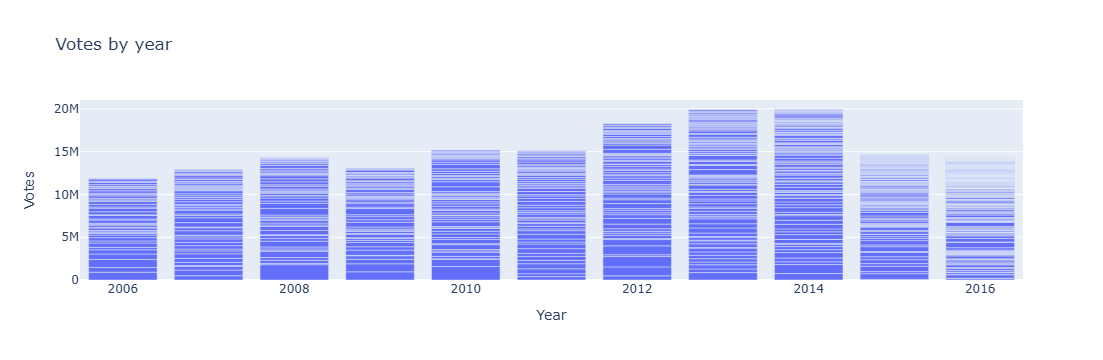

In [77]:
# fig = px.bar(df, x='Year', y='Votes',title='Votes by year')
# fig.show()

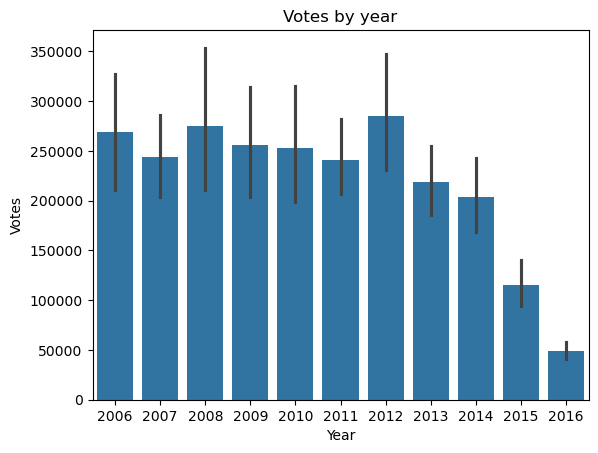

In [78]:
sns.barplot(x='Year',y='Votes', data=df)
plt.title('Votes by year')
plt.show()

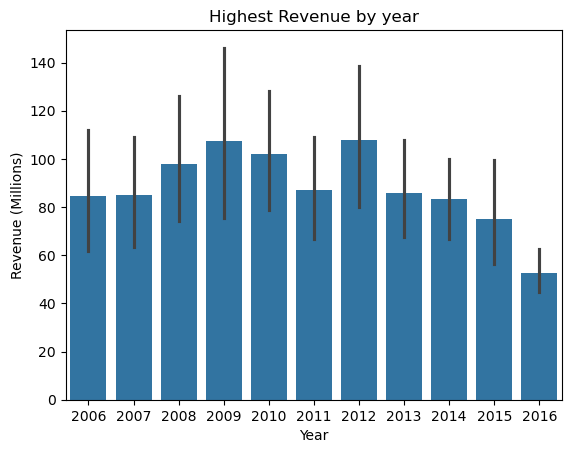

In [79]:
sns.barplot(x='Year',y='Revenue (Millions)', data=df)
plt.title('Highest Revenue by year')
plt.show()

In [86]:
df.columns

Index(['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year',
       'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)',
       'Metascore'],
      dtype='object')

In [103]:
#average rating for each director
dir_rating = df.groupby('Director')['Rating'].mean().sort_values(ascending=False)
dir_rating.head(10)

Director
Nitesh Tiwari                       8.80
Christopher Nolan                   8.68
Olivier Nakache                     8.60
Makoto Shinkai                      8.60
Florian Henckel von Donnersmarck    8.50
Aamir Khan                          8.50
Naoko Yamada                        8.40
Damien Chazelle                     8.40
S.S. Rajamouli                      8.30
Thomas Vinterberg                   8.30
Name: Rating, dtype: float64

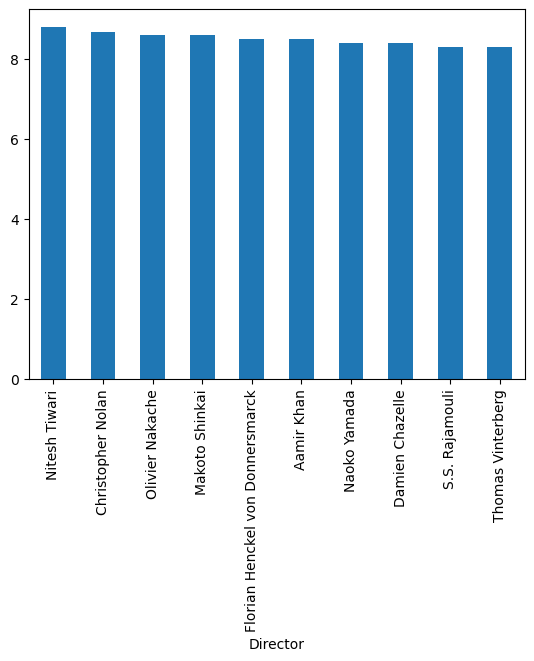

In [102]:
dir_rating.head(10).plot.bar()
plt.show()

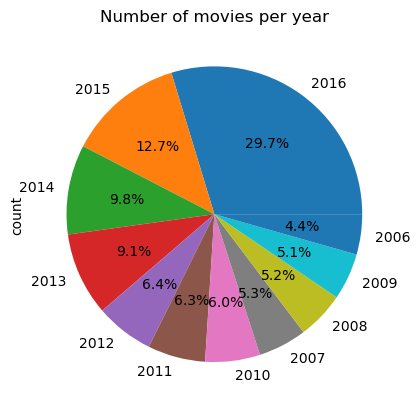

In [111]:
#number of movies per year
df['Year'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Number of movies per year')
plt.show()

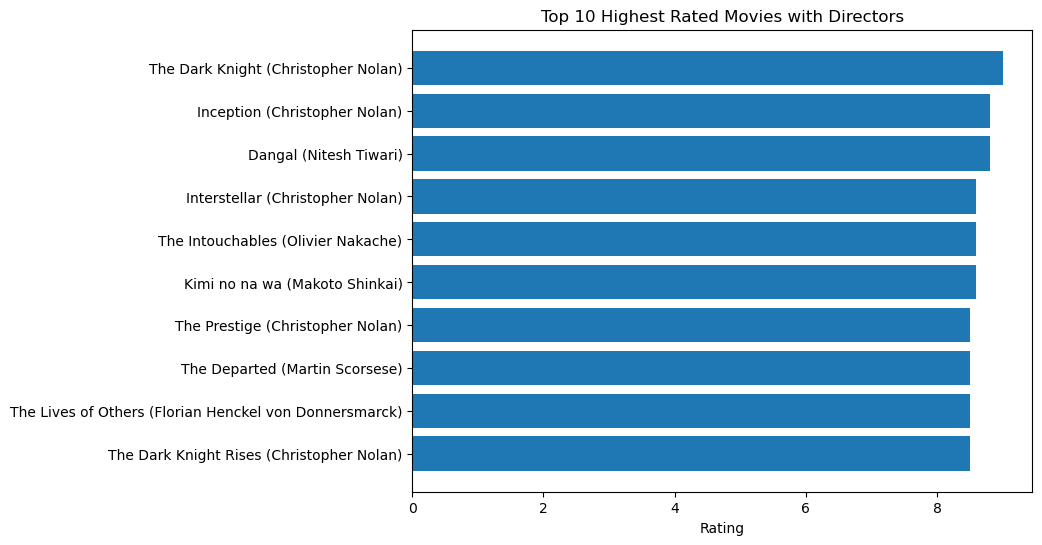

In [199]:
#Top 10 highesr rated movies with their director
top_rated = df.sort_values(by='Rating', ascending=False).head(10)

labels = top_rated['Title'] + " (" + top_rated['Director'] + ")"
plt.figure(figsize=(8,6))
plt.barh(labels, top_rated['Rating'])

plt.xlabel('Rating')
plt.title('Top 10 Highest Rated Movies with Directors')
plt.gca().invert_yaxis()
plt.show()

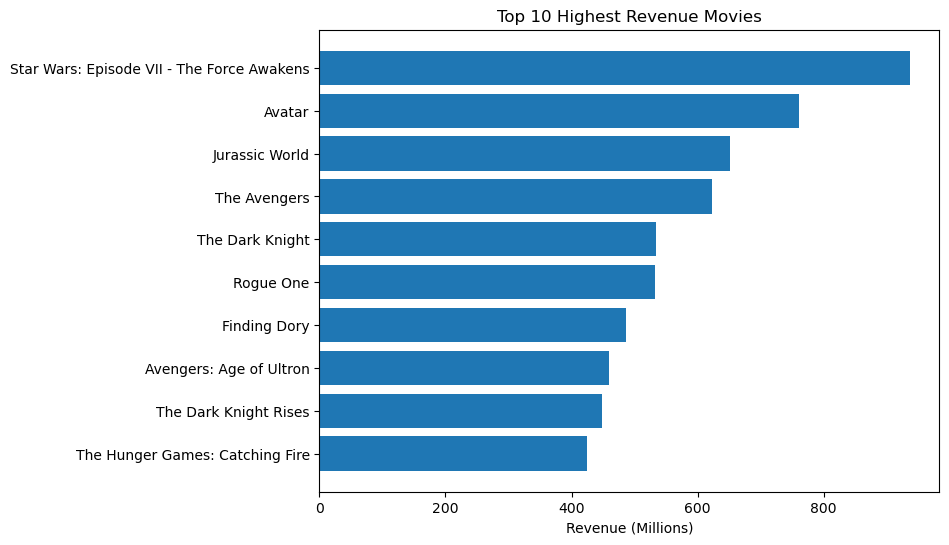

In [118]:
top_rated = df.sort_values(by='Revenue (Millions)', ascending=False).head(10)
# print(top_rated)
plt.figure(figsize=(8,6))

plt.barh(top_rated['Title'], top_rated['Revenue (Millions)'])

plt.xlabel('Revenue (Millions)')
plt.title('Top 10 Highest Revenue Movies')
plt.gca().invert_yaxis()  # highest on top

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

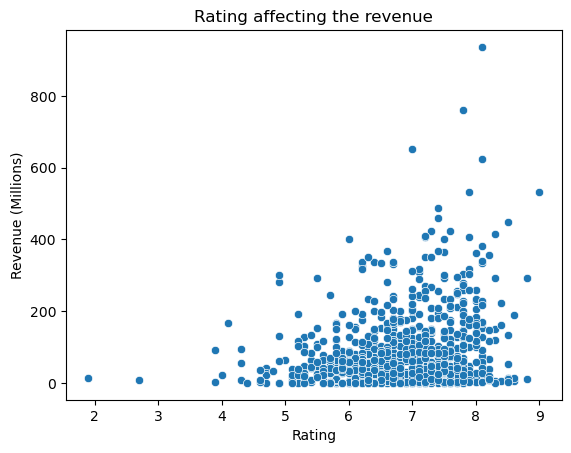

In [12]:
#does rating affect the revenue
sns.scatterplot(x='Rating', y='Revenue (Millions)', data=df)
plt.title('Rating affecting the revenue')
plt.show

### Encoding rating column

In [125]:
def rating(rating):
    if rating>=7.0:
        return "Excellent"
    elif rating>=6.0:
        return "Good"
    else:
        return "Average"

df['rating_new']= df['Rating'].apply(rating)
df['rating_new'].head(10)

0    Excellent
1    Excellent
2    Excellent
3    Excellent
4         Good
5         Good
6    Excellent
7         Good
8    Excellent
9    Excellent
Name: rating_new, dtype: object

### Feature Selection

In [185]:
#feature selection
features = ['Revenue (Millions)', 'Votes', 'Runtime (Minutes)', 'Metascore','Year']
X = df[features]
y = df['Rating']

### Train Test Split

In [186]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Linear Regression model training

In [187]:
#Model Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [188]:
#Prediction
y_pred = model.predict(X_test)

### Evaluation Metrics

In [189]:
# Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.44935995264716866
RMSE:  0.6703431603642784
R2 Score: 0.5312154925000638


### Predicting new movie with Logistic Regression

In [191]:
#predict new movie
new_movie = [[126.46, 	485820	, 124, 65.0, 2012]]  
# [Revenue, Votes, Runtime, Metascore, Year]

predicted_revenue = model.predict(new_movie)

print(predicted_revenue)

[7.54684613]


### Random Forest Model Training

In [192]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [193]:
#Prediction
y_pred = model.predict(X_test)

### Evaluation Metrics

In [194]:
# Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE: ",np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.45068016000000033
RMSE:  0.6713271631626418
R2 Score: 0.5298382163319293


### Predicting new movie with Random forest 

In [195]:
#predict new movie
new_movie = [[126.46, 	485820	, 124, 65.0, 2012]]  
# [Rating, Votes, Runtime]

predicted_revenue = model.predict(new_movie)

print(predicted_revenue)

[7.105]
